Bartlett P-Value: 0.0
KMO Score: 0.6099959032366333


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


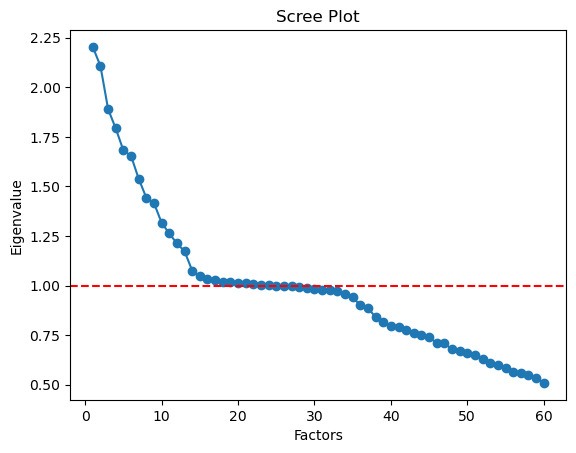

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Top loadings for each factor:

--- Factor 1 ---
You have always been fascinated by the question of what, if anything, happens after death.                              0.396395
You rarely second-guess the choices that you have made.                                                                 0.384321
You usually prefer just doing what you feel like at any given moment instead of planning a particular daily routine.    0.320496
You tend to avoid drawing attention to yourself.                                                                        0.294039
You often make a backup plan for a backup plan.                                                                         0.273125
Name: Factor 1, dtype: float64

--- Factor 2 ---
You enjoy watching people argue.                                                                                        0.375484
You often make a backup plan for a backup plan.                                                                         0.359048

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

# 1. Load Data
df = pd.read_csv('/data/demo_data/16_personality/16P.csv', encoding="cp1252")
# Dropping non-numeric identifiers and the label column
x = df.drop(columns=['Response Id', 'Personality'])

# 2. Suitability Tests
chi_square_value, p_value = calculate_bartlett_sphericity(x)
kmo_all, kmo_model = calculate_kmo(x)
print(f"Bartlett P-Value: {p_value}")
print(f"KMO Score: {kmo_model}")

# 3. Determine Optimal Factors (Scree Plot)
fa = FactorAnalyzer(rotation=None)
fa.fit(x)
ev, v = fa.get_eigenvalues()

plt.scatter(range(1, x.shape[1]+1), ev)
plt.plot(range(1, x.shape[1]+1), ev)
plt.title('Scree Plot')
plt.xlabel('Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

# 4. Perform Factor Analysis
# Choosing 5 factors based on the 16P framework (Extraversion, Intuition, Feeling, Judging, Assertiveness)
n_factors = 5
fa = FactorAnalyzer(n_factors, rotation="varimax")
fa.fit(x)

# 5. Get Factor Loadings
loadings = pd.DataFrame(fa.loadings_, index=x.columns, columns=[f"Factor {i+1}" for i in range(n_factors)])
print("\nTop loadings for each factor:")
for i in range(1, n_factors + 1):
    print(f"\n--- Factor {i} ---")
    print(loadings[f"Factor {i}"].sort_values(ascending=False).head(5))

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed 

Factors based on Kaiser Criterion: 25
Factors based on Parallel Analysis: 17


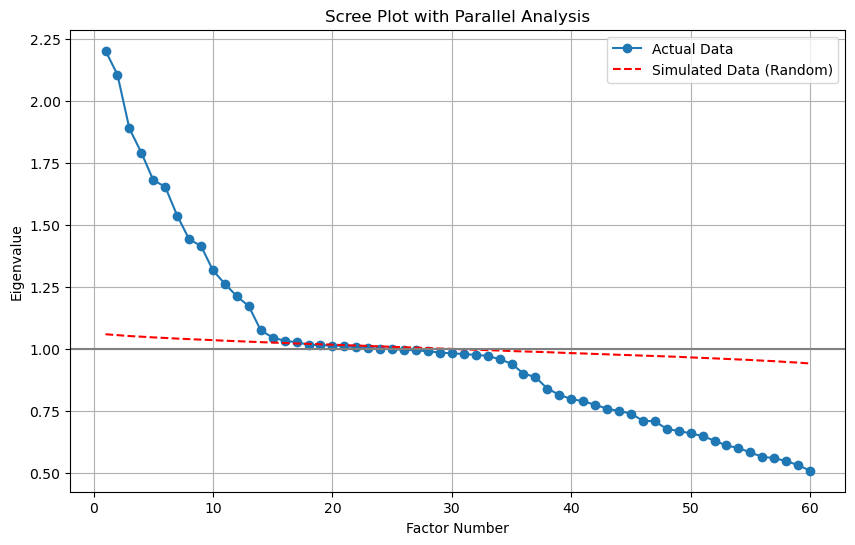

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



--- Factor Naming Based on Top Loadings ---

Factor_1 Top Questions:
You prefer to completely finish one project before starting another.                             0.456529
If your plans are interrupted, your top priority is to get back on track as soon as possible.    0.406368
You enjoy watching people argue.                                                                 0.335215
Name: Factor_1, dtype: float64

Factor_2 Top Questions:
Seeing other people cry can easily make you feel like you want to cry too                               0.557187
You rarely worry about whether you make a good impression on people you meet.                           0.452967
You feel comfortable just walking up to someone you find interesting and striking up a conversation.    0.349066
Name: Factor_2, dtype: float64

Factor_3 Top Questions:
At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know       0.668481
You often make a backup plan for

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from factor_analyzer import FactorAnalyzer

# 1. Load and clean data

# Exclude non-numeric and label columns
X = df.drop(columns=['Response Id', 'Personality'])

# 2. Initial Fit to get Eigenvalues
fa = FactorAnalyzer(rotation=None)
fa.fit(X)
ev, v = fa.get_eigenvalues()

# 3. Parallel Analysis (Generating random data for comparison)
def parallel_analysis(data, iterations=20):
    n_obs, n_vars = data.shape
    rng_eigenvalues = []
    for _ in range(iterations):
        # Create random noise with the same dimensions as our data
        random_data = np.random.normal(size=(n_obs, n_vars))
        fa_random = FactorAnalyzer(rotation=None)
        fa_random.fit(random_data)
        ev_random, _ = fa_random.get_eigenvalues()
        rng_eigenvalues.append(ev_random)
    return np.mean(rng_eigenvalues, axis=0)

avg_rng_ev = parallel_analysis(X)

# 4. Determine Optimal Number of Factors
# Kaiser Criterion: Count factors with eigenvalues > 1
kaiser_factors = sum(ev > 1)

# Parallel Analysis Criterion: Count factors where actual EV > random EV
pa_factors = sum(ev > avg_rng_ev)

print(f"Factors based on Kaiser Criterion: {kaiser_factors}")
print(f"Factors based on Parallel Analysis: {pa_factors}")

# 5. Visualize (Scree Plot + Parallel Analysis)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(ev)+1), ev, 'o-', label='Actual Data')
plt.plot(range(1, len(avg_rng_ev)+1), avg_rng_ev, 'r--', label='Simulated Data (Random)')
plt.axhline(y=1, color='gray', linestyle='-')
plt.title('Scree Plot with Parallel Analysis')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.legend()
plt.grid(True)
plt.show()

# 6. Final Factor Analysis (Using the Parallel Analysis result)
# Typically, PA is the most reliable. We'll proceed with pa_factors.
final_fa = FactorAnalyzer(n_factors=pa_factors, rotation="varimax")
final_fa.fit(X)

# 7. Name the Factors
loadings = pd.DataFrame(final_fa.loadings_, index=X.columns, 
                        columns=[f"Factor_{i+1}" for i in range(pa_factors)])

print("\n--- Factor Naming Based on Top Loadings ---")
for col in loadings.columns:
    print(f"\n{col} Top Questions:")
    print(loadings[col].abs().sort_values(ascending=False).head(3))

Factor,Factor Name,Primary Indicators (Top Questions)

1,Self-Assurance,Rarely second-guessing choices; not avoiding attention.

2,Social Spontaneity,Acting on impulse; comfortable starting conversations with strangers.

3,Stress Resilience,Staying calm under pressure; not feeling overwhelmed.

4,Intellectual Interpretation,Preferring interpretive art/media; analytical mindset.

5,Affective Empathy,Feeling emotional resonance with others; social warmth.

6,Structured Organization,"High reliance on schedules, lists, and organizing tools."

7,Pragmatic Rationalism,Following the head over the heart; focusing on personal progress.

8,Social Proactivity,Initiating contact with friends; avoiding procrastination.

9,Task Persistence,Finishing one project before starting another; focused interest.

10,Social Reservedness,Sticking to known people at events; avoiding the spotlight.

11,Sensory Seeking,"Drawn to busy, bustling environments and lively social events."

12,Emotional Regulation,Balance between emotional control and understanding diverse views.

13,Time Management,Tendency to avoid last-minute rushes and meet deadlines.

14,Dynamic Responsiveness,Rapid mood changes coupled with a need for social stimulus.

15,Artistic Indifference,"Identifying as ""not an artistic type""; preference for simplicity."

16,Social Altruism,Finding happiness in helping others; caring about impressions.

17,Decisive Practicality,Certainty in choices; lack of interest in complex analyses.

Silhouette Score for 4 clusters: 0.0715687816688604
Silhouette Score for 5 clusters: 0.07814261913304568
Silhouette Score for 6 clusters: 0.08413807860821856
               F1        F2        F3        F4        F5        F6        F7  \
Cluster                                                                         
0       -0.066362  0.396324 -0.419040  0.783822 -0.486266  0.003078  0.364851   
1        0.814566  0.561469  0.107445 -0.551040 -0.096541  0.052224  0.220368   
2        0.326956 -0.702163  0.646696  0.341736  0.127020  0.348296 -0.027083   
3       -0.838978  0.554308  0.175759  0.005556  0.416591 -0.082737 -0.204310   
4       -0.261553 -0.770559 -0.605782 -0.399443 -0.066313 -0.320730 -0.284516   

               F8        F9       F10       F11       F12       F13       F14  \
Cluster                                                                         
0       -0.340216 -0.219236  0.178960  0.245701  0.008405 -0.065724 -0.022511   
1        0.164002  0.220754 -0.

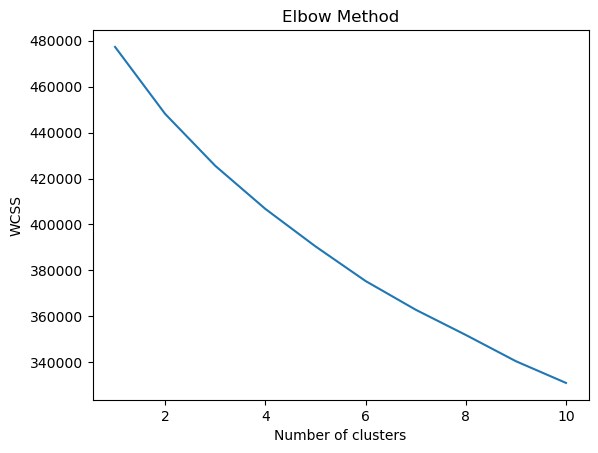

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data


# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Factor Analysis (17 factors as identified)
n_factors = 17
fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(X_scaled)

# Determine optimal clusters using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.savefig('elbow_plot.png')

# Let's also check Silhouette score for 4, 5, 6
for n in range(4, 7):
    km = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = km.fit_predict(factor_scores)
    score = silhouette_score(factor_scores, labels)
    print(f"Silhouette Score for {n} clusters: {score}")

# Using 5 clusters for interpretability
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(factor_scores)

# Analyze clusters
df_factors = pd.DataFrame(factor_scores, columns=[f"F{i+1}" for i in range(n_factors)])
df_factors['Cluster'] = cluster_labels
cluster_means = df_factors.groupby('Cluster').mean()

print(cluster_means)

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Factor Analysis (17 factors)
n_factors = 17
fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(X_scaled)

# Determine number of clusters
# Using a subset for speed if needed, but 60k is manageable for KMeans.
# We'll test 3 to 6 clusters.
inertia = []
K = range(2, 7)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    inertia.append(kmeans.inertia_)

print("Inertia values:", inertia)

# Let's pick 4 clusters for distinct personality archetypes
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(factor_scores)

# Add cluster labels to the data
df_factors = pd.DataFrame(factor_scores, columns=[f"F{i+1}" for i in range(n_factors)])
df_factors['Cluster'] = clusters

# Profile clusters by averaging factor scores
cluster_profiles = df_factors.groupby('Cluster').mean()

print(cluster_profiles)

Inertia values: [448115.65528234997, 425526.993432968, 406760.1303033578, 390448.6178999745, 375372.5476432851]
               F1        F2        F3        F4        F5        F6        F7  \
Cluster                                                                         
0       -0.308739 -0.749771 -0.533739 -0.383976 -0.115419 -0.265843 -0.218772   
1        0.251938 -0.293180  0.298653  0.879660 -0.315684  0.021598 -0.018292   
2       -0.717488  0.474095  0.122797  0.004456  0.442977  0.064695  0.007401   
3        0.811237  0.473585  0.076564 -0.497540 -0.061457  0.157216  0.213259   

               F8        F9       F10       F11       F12       F13       F14  \
Cluster                                                                         
0       -0.008308  0.154227 -0.003037  0.187075 -0.024174  0.033520 -0.035172   
1        0.023769 -0.141093  0.054834 -0.132572 -0.042891 -0.011772  0.059204   
2       -0.119058 -0.114426 -0.002942 -0.069656  0.130753 -0.055010  0.015368

Cluster	Name	Description
0	The Reserved Traditionalists	This group is characterized by a high degree of caution and a preference for well-established routines over social or intellectual novelty. They are highly reliable in structured settings and excel at maintaining order through consistent, methodical work habits. Their main limitations include a vulnerability to stress in unpredictable environments and a tendency to withdraw when faced with complex social or abstract challenges.

1	The Cerebral Analysts	These individuals prioritize deep intellectual inquiry and logical interpretation, often preferring the world of ideas to the bustle of social interaction. They possess superior critical thinking skills and the ability to remain objective when processing complex, abstract information. However, they may struggle with interpersonal warmth and social spontaneity, occasionally appearing overly critical or detached from the emotional climate of their surroundings.

2	The Harmonious Connectors	This cluster is defined by a strong emotional resonance with others and a spontaneous, warm approach to social engagement. Their greatest strengths are their profound empathy and their ability to foster inclusive, supportive environments through genuine interpersonal connection. Conversely, they often grapple with low self-assurance and may find it difficult to maintain focus on pragmatic goals when their emotional state is unsettled.

3	The Decisive Strategists	Members of this cluster exhibit high self-confidence and a results-oriented mindset, moving through life with energy and clear pragmatic purpose. They are distinguished by their exceptional resilience under pressure and their capacity to lead social groups toward tangible outcomes. A potential weakness is their tendency to dismiss abstract or artistic nuances as impractical, which can lead to a narrow focus on efficiency at the expense of depth.

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans


# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Factor Analysis (Using the 17 factors identified)
n_factors = 17
fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(X_scaled)

# 4. Clustering (Assigning to one of the 4 archetypes)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(factor_scores)

# 5. Extract Profile for Person 12 (Response Id 12)
person_idx = df[df['Response Id'] == 12].index[0]
p12_scores = factor_scores[person_idx]
p12_cluster = clusters[person_idx]

# 6. Identify Strengths and Weaknesses
# Finding the highest and lowest factor scores for Person 12
top_factor_idx = np.argmax(p12_scores)
bottom_factor_idx = np.argmin(p12_scores)

print(f"Person 12 Cluster: {p12_cluster}")
print(f"Top Factor Score: {p12_scores[top_factor_idx]:.2f} (Factor {top_factor_idx + 1})")
print(f"Bottom Factor Score: {p12_scores[bottom_factor_idx]:.2f} (Factor {bottom_factor_idx + 1})")

Person 12 Cluster: 1
Top Factor Score: 0.92 (Factor 3)
Bottom Factor Score: -2.00 (Factor 2)


Person 12 exhibits strong intellectual depth and cognitive resilience, characterized by a high capacity for complex interpretation and a superior ability to maintain composure under professional or environmental pressure. In contrast, they show significant weaknesses in social engagement and emotional resonance, appearing notably detached from the feelings of others and demonstrating a strong aversion to spontaneous or bustling social activities. Ultimately, Person 12 is a highly analytical and stoic individual who prioritizes structured logic and internal reflection over external social stimulation.